In [1]:
import pandas as pd
import os
from utils import buildDataset, analyze_svm_results
import numpy as np
from ovoSVM import OneVsOneSVM
import time

# for validation
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Question 2:: Multi Image Classification
inputClasses = list(range(10))
print(f"Running for classes : {inputClasses}")
results = {}
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

Running for classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [3]:
print("------Building train set------")
trainingSet = buildDataset(basePath="train", inputClasses = inputClasses)
trainingSet.head()

------Building train set------
Loaded airplane → X: (1667, 3072), y: (1667,)
Loaded automobile → X: (1667, 3072), y: (1667,)
Loaded bird → X: (1667, 3072), y: (1667,)
Loaded cat → X: (1667, 3072), y: (1667,)
Loaded deer → X: (1667, 3072), y: (1667,)
Loaded dog → X: (1667, 3072), y: (1667,)
Loaded frog → X: (1667, 3072), y: (1667,)
Loaded horse → X: (1667, 3072), y: (1667,)
Loaded ship → X: (1667, 3072), y: (1667,)
Loaded truck → X: (1667, 3072), y: (1667,)
Suffling to mix both classes

Final Dataset Shape train: (16670, 3073)


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,0.960784,0.980392,0.992157,0.960784,0.984314,0.984314,0.960784,0.984314,0.984314,0.960784,...,0.431373,0.427451,0.419608,0.431373,0.423529,0.435294,0.431373,0.423529,0.435294,8
1,0.427451,0.635294,0.756863,0.419608,0.619608,0.725490,0.403922,0.580392,0.662745,0.415686,...,0.160784,0.352941,0.470588,0.176471,0.372549,0.470588,0.188235,0.384314,0.474510,8
2,0.678431,0.635294,0.611765,0.725490,0.682353,0.658824,0.721569,0.670588,0.647059,0.596078,...,0.862745,0.792157,0.792157,0.764706,0.694118,0.694118,0.756863,0.686275,0.686275,6
3,0.254902,0.180392,0.188235,0.337255,0.266667,0.258824,0.341176,0.274510,0.243137,0.392157,...,0.176471,0.164706,0.145098,0.196078,0.156863,0.149020,0.168627,0.125490,0.117647,6
4,0.968627,1.000000,1.000000,0.968627,1.000000,1.000000,0.976471,1.000000,1.000000,0.980392,...,1.000000,0.988235,0.980392,1.000000,0.988235,0.992157,1.000000,0.984314,0.988235,9


In [4]:
print("------Building test set------")
testingSet = buildDataset(basePath="test", inputClasses = inputClasses)
testingSet.head()

------Building test set------
Loaded airplane → X: (333, 3072), y: (333,)
Loaded automobile → X: (333, 3072), y: (333,)
Loaded bird → X: (333, 3072), y: (333,)
Loaded cat → X: (333, 3072), y: (333,)
Loaded deer → X: (333, 3072), y: (333,)
Loaded dog → X: (333, 3072), y: (333,)
Loaded frog → X: (333, 3072), y: (333,)
Loaded horse → X: (333, 3072), y: (333,)
Loaded ship → X: (333, 3072), y: (333,)
Loaded truck → X: (333, 3072), y: (333,)
Suffling to mix both classes

Final Dataset Shape test: (3330, 3073)


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,0.431373,0.215686,0.188235,0.400000,0.207843,0.192157,0.313726,0.145098,0.172549,0.227451,...,0.556863,0.533333,0.572549,0.560784,0.521569,0.552941,0.556863,0.521569,0.541176,1
1,0.011765,0.000000,0.007843,0.015686,0.000000,0.011765,0.023529,0.000000,0.007843,0.023529,...,0.023529,0.007843,0.003922,0.019608,0.003922,0.000000,0.019608,0.003922,0.000000,5
2,0.317647,0.301961,0.290196,0.286275,0.270588,0.258824,0.258824,0.254902,0.239216,0.254902,...,0.098039,0.137255,0.105882,0.078431,0.105882,0.074510,0.094118,0.121569,0.090196,2
3,0.549020,0.552941,0.388235,0.858824,0.866667,0.709804,0.835294,0.854902,0.698039,0.847059,...,0.254902,0.356863,0.172549,0.176471,0.223529,0.066667,0.243137,0.274510,0.129412,5
4,0.968627,0.992157,1.000000,0.949020,0.972549,1.000000,0.870588,0.890196,0.964706,0.713726,...,0.360784,0.313726,0.211765,0.372549,0.329412,0.211765,0.439216,0.400000,0.262745,9


In [5]:
# Training Multi Image Classification problem with a gaussian kernel using CVXOPT package
ovo_svm_gaussian = OneVsOneSVM(C=1.0, gamma=0.001, kernel='gaussian')
X_train, y_train = trainingSet.iloc[:, :-1], trainingSet.iloc[:, -1]
X_test, y_test = testingSet.iloc[:, :-1], testingSet.iloc[:, -1]

startTime = time.time()
ovo_svm_gaussian.fit(X_train, y_train)

training_time_cvxopt = time.time() - startTime
print(f"  custom SVM training ran in   : {training_time_cvxopt:.4f}s")

preds_train_cvxopt = ovo_svm_gaussian.predict(X_train)
train_acc_cvxopt = np.mean(preds_train_cvxopt == y_train)
print(f"Custom SVM :: Train Accuracy with Gaussian Kernel OVO SVM: {train_acc_cvxopt*100:.2f}%).")

# 5 a) Classifying the test examples and reporing the test set accuracy
preds_test_cvxopt = ovo_svm_gaussian.predict(X_test)
test_acc_cvxopt = np.mean(preds_test_cvxopt == y_test)

print(f"5 a) Custom SVM :: Test Accuracy with Gaussian Kernel OVO SVM: {test_acc_cvxopt*100:.2f}%).")

Training 45 One-vs-One classifiers...
  custom SVM training ran in   : 771.7714s
Custom SVM :: Train Accuracy with Gaussian Kernel OVO SVM: 48.31%).
5 a) Custom SVM :: Test Accuracy with Gaussian Kernel OVO SVM: 43.84%).


In [6]:
# 6) Scikit-learn MULTI-CLASS SVM Question
X_train, y_train = trainingSet.iloc[:, :-1], trainingSet.iloc[:, -1]
X_test, y_test = testingSet.iloc[:, :-1], testingSet.iloc[:, -1]

print("===== Scikit-learn (LIBSVM) Multi-Class SVM =====")

# (a) Train scikit-learn’s multi-class SVM
start_time = time.time()
sk_svm_rbf = SVC(
    kernel='rbf',
    C=1.0,
    gamma=0.001,
    decision_function_shape='ovo'  # one-vs-one multi-class setting
)
sk_svm_rbf.fit(X_train, y_train)
train_time_sklearn = time.time() - start_time

# Predictions
y_pred_train_sklearn = sk_svm_rbf.predict(X_train)
y_pred_test_sklearn = sk_svm_rbf.predict(X_test)

# Accuracy
train_acc_sklearn = accuracy_score(y_train, y_pred_train_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_pred_test_sklearn)

print(f"(a) Train Accuracy : {train_acc_sklearn * 100:.2f}%")
print(f"    Test Accuracy  : {test_acc_sklearn * 100:.2f}%")
print(f"(b) Training Time  : {train_time_sklearn:.3f}s")

===== Scikit-learn (LIBSVM) Multi-Class SVM =====
(a) Train Accuracy : 48.24%
    Test Accuracy  : 43.66%
(b) Training Time  : 339.154s


In [7]:
# ---- 6 b) Compare CVXOPT (custom) vs scikit-learn (LIBSVM) ----
print("\n===== Multi-class SVM Comparison (Gaussian Kernel) =====")

print(f"(a) Test Accuracy:")
print(f"  CVXOPT OVO SVM   : {test_acc_cvxopt*100:.2f}%")
print(f"  sklearn (LIBSVM) : {test_acc_sklearn*100:.2f}%")

print(f"\n(b) Training Time (seconds):")
print(f"  CVXOPT OVO SVM   : {training_time_cvxopt:.4f}s")
print(f"  sklearn (LIBSVM) : {train_time_sklearn:.4f}s")

# Optional: relative comparison
print("\nSummary:")
if test_acc_sklearn > test_acc_cvxopt:
    print(f"sklearn achieved higher accuracy (+{test_acc_sklearn*100 - test_acc_cvxopt*100:.2f}%).")
else:
    print(f"CVXOPT achieved slightly higher accuracy (+{test_acc_cvxopt*100 - test_acc_sklearn*100:.2f}%).")

if train_time_sklearn < training_time_cvxopt:
    print(f"sklearn was faster by {training_time_cvxopt - train_time_sklearn:.2f} seconds.")
else:
    print(f"CVXOPT was faster by {train_time_sklearn - training_time_cvxopt:.2f} seconds.")


===== Multi-class SVM Comparison (Gaussian Kernel) =====
(a) Test Accuracy:
  CVXOPT OVO SVM   : 43.84%
  sklearn (LIBSVM) : 43.66%

(b) Training Time (seconds):
  CVXOPT OVO SVM   : 771.7714s
  sklearn (LIBSVM) : 339.1540s

Summary:
CVXOPT achieved slightly higher accuracy (+0.18%).
sklearn was faster by 432.62 seconds.


In [10]:
def plotConfusionMatrix(y_test, y_preds, class_names, title = ""):
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_preds, labels=range(len(class_names)))
    plt.figure(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    save_path = os.path.join("images", title)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def misClassifiedExamples(y_test, y_pred, class_names, title = ""):
    # Find misclassified indices (for CVXOPT model)
    mis_idx = np.where(y_pred != y_test)[0]
    
    print(f"Total misclassified samples: {len(mis_idx)}")
    print("Showing 10 examples...\n")
    
    num_show = min(10, len(mis_idx))
    plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(mis_idx[:num_show]):
        img = X_test.iloc[idx].to_numpy().reshape(32, 32, 3)
        plt.subplot(2, 5, i+1)
        plt.imshow((img - img.min()) / (img.max() - img.min()))  # normalize for display
        true_label = class_names[int(y_test.iloc[idx])]
        pred_label = class_names[int(y_pred[idx])]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis("off")
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    save_path = os.path.join("images", title)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


===== Confusion Matrices =====


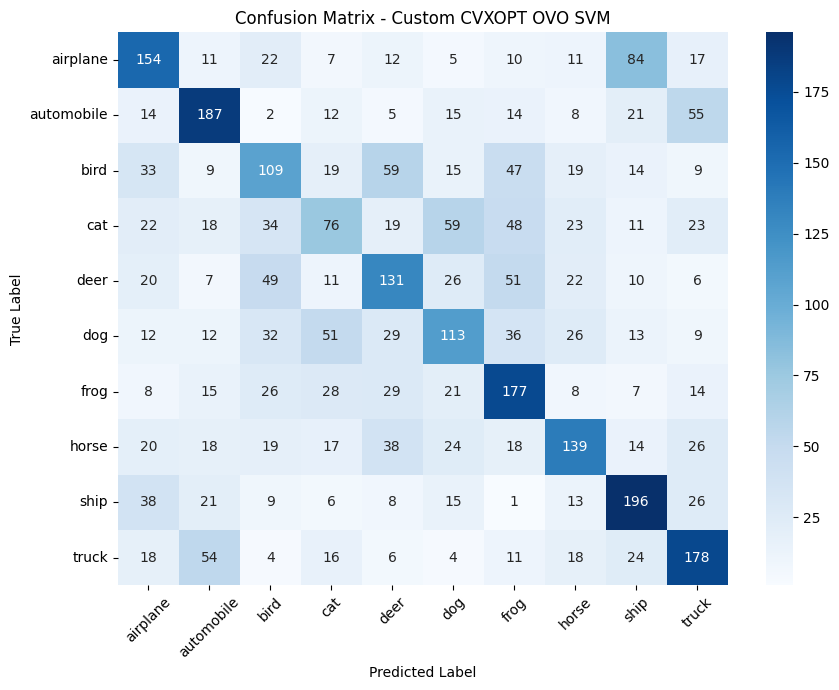

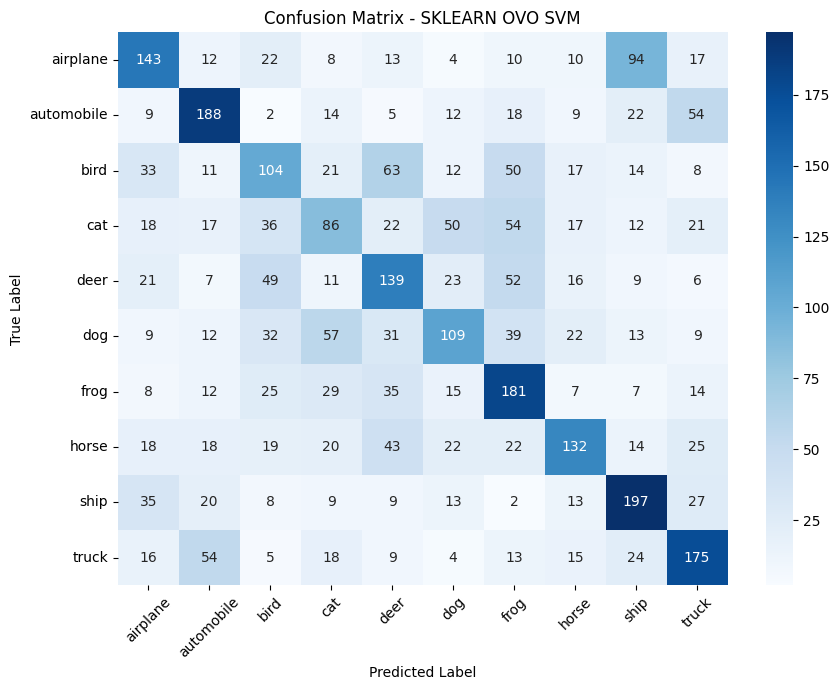


===== Misclassified Examples (CVXOPT OVO SVM) =====
Total misclassified samples: 1870
Showing 10 examples...



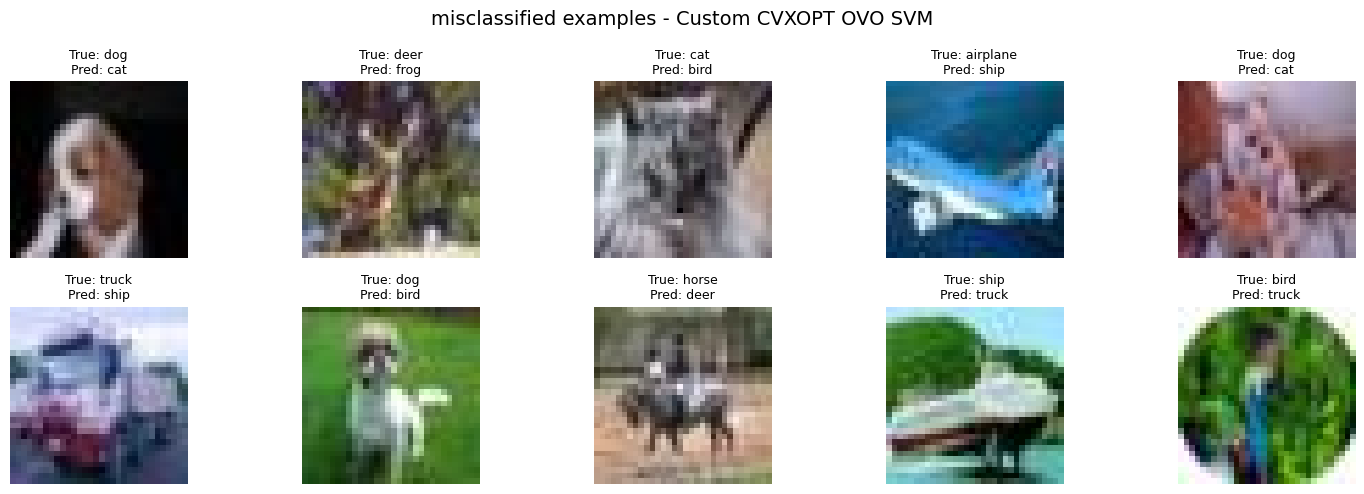


===== Misclassified Examples (sklearn OVO SVM) =====
Total misclassified samples: 1876
Showing 10 examples...



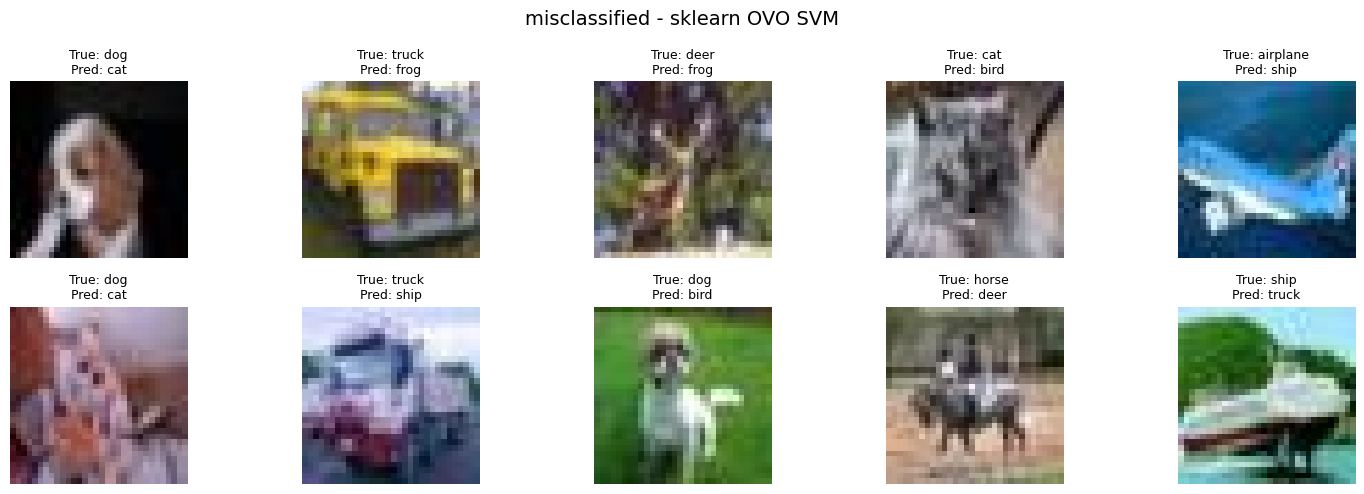

In [12]:
# -----------------------------
# 7(a) Confusion Matrices
# -----------------------------
print("\n===== Confusion Matrices =====")

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

# CVXOPT Confusion Matrix
plotConfusionMatrix(y_test, preds_test_cvxopt, class_names, title = "Confusion Matrix - Custom CVXOPT OVO SVM")

# LIBSVM Confusion Matrix
plotConfusionMatrix(y_test, y_pred_test_sklearn, class_names, "Confusion Matrix - SKLEARN OVO SVM")

# -----------------------------
# 7(b) Misclassified Examples
# -----------------------------
print("\n===== Misclassified Examples (CVXOPT OVO SVM) =====")
misClassifiedExamples(y_test, preds_test_cvxopt, class_names, title = "misclassified examples - Custom CVXOPT OVO SVM")

print("\n===== Misclassified Examples (sklearn OVO SVM) =====")
misClassifiedExamples(y_test, y_pred_test_sklearn, class_names, title = "misclassified - sklearn OVO SVM")

In [15]:
# -----------------------------
# 7(c) Observations
# -----------------------------
print("\n===== Observations =====")
print("• The confusion matrices show which classes are most often confused.")
print("• Diagonal entries represent correct classifications.")
print("• Off-diagonal entries indicate misclassifications.")
print("• Common pattern: visually similar classes — for instance:")
print("   - Misclassified images are mostly Blury image -")
print("   - Structure of truck and ship/ aeroplane or ship resembled same in those blurry picktures so got misclassified")
print("• The LIBSVM model generally shows slightly fewer confusions (stronger diagonals)")
print("  due to numerical precision and solver optimization advantages over CVXOPT.")


===== Observations =====
• The confusion matrices show which classes are most often confused.
• Diagonal entries represent correct classifications.
• Off-diagonal entries indicate misclassifications.
• Common pattern: visually similar classes — for instance:
   - Misclassified images are mostly Blury image -
   - Structure of truck and ship/ aeroplane or ship resembled same in those blurry picktures so got misclassified
• The LIBSVM model generally shows slightly fewer confusions (stronger diagonals)
  due to numerical precision and solver optimization advantages over CVXOPT.
